# Modelling

Initial setup for modelling with randomforest, histgradientboosting and xgboost.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import subkart

## Terrain features

In [2]:
RESOLUTION = 50

In [ ]:
gdf_sea_map = subkart.sources.sea_map_basisdata(
    ["Oslo", "Ostfold", "Akershus", "Buskerud", "Vestfold", "Rogaland", "Vestland", "More_og_Romsdal", "Trondelag"]
)
crs = gdf_sea_map.crs

In [4]:
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=RESOLUTION)

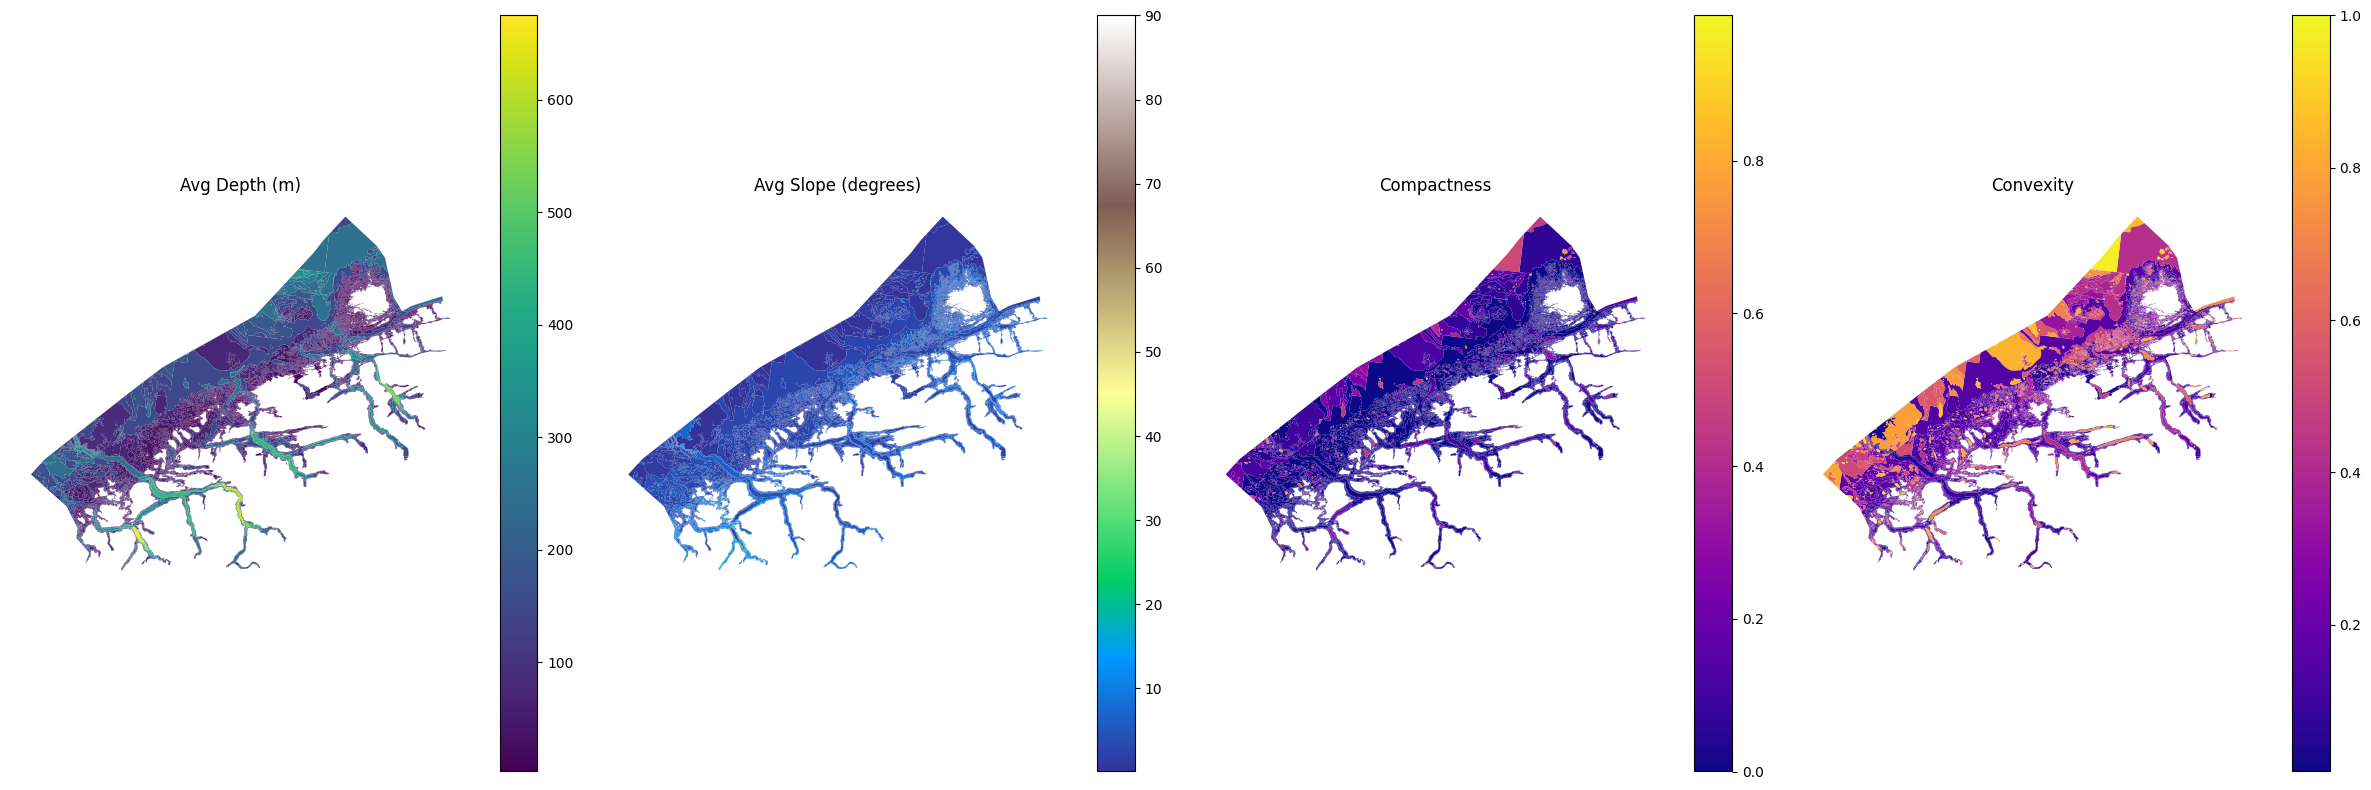

In [5]:
subkart.plot.terrain_features(gdf_sea_map)

## DEM 50

https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-50-meters-grid/67a3a191-49cc-45bc-baf0-eaaf7c513549

In [6]:
dem = subkart.sources.dem_data()

/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1860: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(


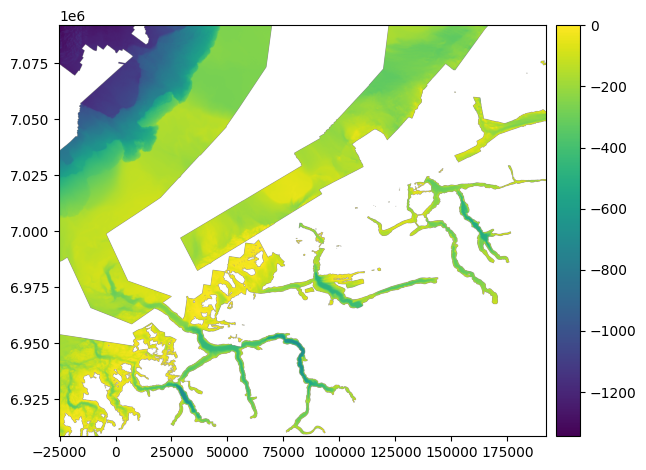

In [7]:
dem = dem.crop(bounds)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)
dem.plot()

### Marine vanntyper features



In [8]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/input/mdir/NyTypologi2022.geo.parquet").to_crs(
    gdf_sea_map.crs
)
marine_vanntyper = subkart.features.marine_vanntyper_preprocess(marine_vanntyper)
minx, miny, maxx, maxy = gdf_sea_map.total_bounds
marine_vanntyper = marine_vanntyper.cx[minx:maxx, miny:maxy]

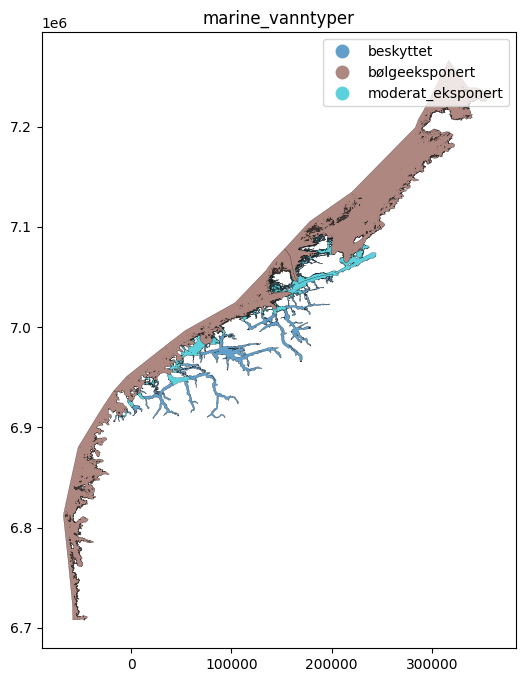

In [9]:
subkart.plot.vanntyper(marine_vanntyper)

## Dataset for labels

In [10]:
gdf_bunn_full = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/results/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet"
)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape=out_shape, transform=transform)
del gdf_bunn_full

## Training

In [11]:
X, valid, out_shape, transform = subkart.features.build(
    dem, gdf_sea_map, marine_vanntyper, valid_bunn, res=RESOLUTION, dtype=np.float16
)

Preparing sea_avg_depth...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_avg_slope...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


...

Preparing sea_convexity...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_area...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/home/kim/work/marint-naturkart-nivaR/subkart/features.py:176: RuntimeWarning: overflow encountered in cast
  data = raster.data.data.astype(dtype, copy=False)


Preparing marine types...
Stacking feature arrays...


In [14]:
y = bunn_raster[valid]  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Baseline

Train a quick baseline for each model

In [ ]:
baseline_models = [
    XGBClassifier(
        num_class=len(classes),
        n_estimators=300,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        tree_method="hist",
    ),
    HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
]

score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - " f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline XGBClassifier - Train: 0.9844, Val: 0.8376


In [34]:
classifier, search_results = subkart.training.optimize_xgboost_hyperparameters(
    X_train, y_train, X_val, y_val, classes
)

Starting search around existing parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Starting randomized search with 50 iterations and 3-fold CV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=1.0, gamma=0.49610577964560876, learning_rate=0.214097781155326, max_depth=6, min_child_weight=6, n_estimators=602, reg_alpha=0.43194501864211576, reg_lambda=0.5824582803960838, subsample=0.8447411578889519; total time=   3.1s
[CV] END colsample_bytree=1.0, gamma=0.49610577964560876, learning_rate=0.214097781155326, max_depth=6, min_child_weight=6, n_estimators=602, reg_alpha=0.43194501864211576, reg_lambda=0.5824582803960838, subsample=0.8447411578889519; total time=   3.9s
[CV] END colsample_bytree=1.0, gamma=0.49610577964560876, learning_rate=0.214097781155326, max_depth=6, min_child_weight=6, n_estimators=602, reg_alpha=0.43194501864211576, reg_lambda=0.5824582803960838, subsample=0.84474

## Random Search

Search through hyperparameters for each model, this can take some time

In [ ]:
is_random_search = False

if is_random_search:
    classifier = subkart.training.random_search(X_train, y_train, X_val, y_val, classes, class_weights)


Fitting 2 folds for each of 80 candidates, totalling 160 fits


[CV 1/2] END model=HistGradientBoostingClassifier(class_weight={0: 0.5641692133611956,
                                             1: 5.059842412465682,
                                             2: 0.9710175173934447},
                               random_state=42), model__l2_regularization=0.1, model__learning_rate=0.05, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=63, model__min_samples_leaf=20;, score=0.650 total time=  21.9s


[CV 2/2] END model=HistGradientBoostingClassifier(class_weight={0: 0.5641692133611956,
                                             1: 5.059842412465682,
                                             2: 0.9710175173934447},
                               random_state=42), model__l2_regularization=0.1, model__learning_rate=0.05, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=63, model__min_samples_leaf=20;, score=0.650 total time=  22.0s


[CV 1/2] END model=HistGradientBoostingClassifier(class_weight={0: 0.5641692133611956,
                                             1: 5.059842412465682,
                                             2: 0.9710175173934447},
                               random_state=42), model__l2_regularization=0.1, model__learning_rate=0.1, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=31, model__min_samples_leaf=20;, score=0.648 total time=  17.0s


[CV 2/2] END model=HistGradientBoostingClassifier(class_weight={0: 0.5641692133611956,
                                             1: 5.059842412465682,
                                             2: 0.9710175173934447},
                               random_state=42), model__l2_regularization=0.1, model__learning_rate=0.1, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=31, model__min_samples_leaf=20;, score=0.650 total time=  17.0s


...

[CV 1/2] END model=HistGradientBoostingClassifier(class_weight={0: 0.5641692133611956,
                                             1: 5.059842412465682,
                                             2: 0.9710175173934447},
                               random_state=42), model__l2_regularization=0.0, model__learning_rate=0.05, model__max_bins=255, model__max_depth=12, model__max_leaf_nodes=31, model__min_samples_leaf=100;, score=0.632 total time=  18.2s


[CV 2/2] END model=HistGradientBoostingClassifier(class_weight={0: 0.5641692133611956,
                                             1: 5.059842412465682,
                                             2: 0.9710175173934447},
                               random_state=42), model__l2_regularization=0.0, model__learning_rate=0.05, model__max_bins=255, model__max_depth=12, model__max_leaf_nodes=31, model__min_samples_leaf=100;, score=0.633 total time=  18.3s


HistGradientBoostingClassifier: mean_test_score=0.6819, params={'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_depth': None, 'max_bins': 255, 'learning_rate': 0.2, 'l2_regularization': 0.1}
XGBClassifier: mean_test_score=0.7696, params={'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
RandomForestClassifier: mean_test_score=0.7158, params={'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 20}


Train accuracy: 0.7904938285074226


Validation accuracy: 0.7735680944960351


In [ ]:
dump(classifier, subkart.utils.model_dir_path() / "classifier.joblib")

['../data_generated/classifier.joblib']

dem_curvature: mean=0.088732, std=0.005194
sea_compactness: mean=0.076526, std=0.005228
sea_convexity: mean=0.074178, std=0.006012
sea_avg_depth: mean=0.039765, std=0.004044
dem_depth: mean=0.039624, std=0.004184
dem_slope: mean=0.038545, std=0.002425
sea_area: mean=0.036291, std=0.003501
sea_avg_slope: mean=0.034038, std=0.004606
bølgeeksponert: mean=0.017653, std=0.002826
beskyttet: mean=0.001784, std=0.001651
moderat_eksponert: mean=0.001221, std=0.001412
is_dem: mean=0.000986, std=0.000902


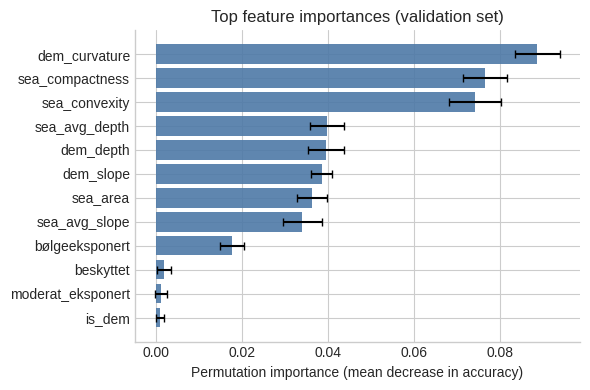

In [31]:
subkart.plot.feature_importance(classifier, X_val, y_val)

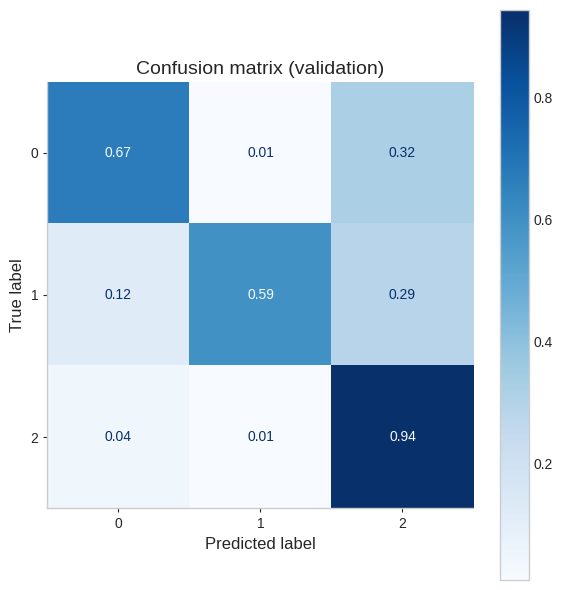

In [ ]:
# Predict on validation set
y_val_pred = classifier.predict(X_val)

# Compute confusion matrix (normalized by true class)
cm = confusion_matrix(y_val, y_val_pred, labels=classes, normalize="true")

subkart.plot.confusion_matrix(cm, classes)

In [33]:
# Print classification report
print("Classification report (validation):")
report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=classes,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df


Classification report (validation):


,precision,recall,f1-score,support
0,0.837161,0.669449,0.743970,599.000000
1,0.766990,0.593985,0.669492,133.000000
2,0.851421,0.942775,0.894773,1398.000000
accuracy,0.844131,0.844131,0.844131,0.844131
macro avg,0.818524,0.735403,0.769411,2130.000000
weighted avg,0.842139,0.844131,0.838297,2130.000000
